## Vijay Hanumandla  23102C0071
Subject: AML

EXPERIMENT NO: 02

#1) Theory

Kernel methods are techniques used in machine learning to handle complex relationships in data. Kernels allow algorithms to operate in a higher-dimensional feature space without explicitly transforming the data.

### 1. Polynomial Kernel

The Polynomial kernel is used to model non-linear relationships between input features.

The polynomial kernel is given by:

K(x, y) = (γ(x · y) + r)^d

where:

- γ is the kernel coefficient
- r is the coefficient
- d is the degree of the polynomial

Important hyperparameters include degree, C and gamma.

### 2. Ridge Regression

Ridge Regression is a regularized linear regression technique that uses L2 regularization.

The objective function is:

Loss = MSE + α Σwᵢ²

where α controls the strength of regularization.

A larger value of alpha applies stronger regularization.

### 3. Sigmoid Kernel

The Sigmoid kernel is based on the hyperbolic tangent function.

K(x, y) = tanh(γ(x · y) + r)

It can be used with Support Vector Machines for classification.

### Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best values of model parameters before training.

In this experiment, GridSearchCV is used to search through different combinations of hyperparameters and identify the combination that gives the best performance.

#2) Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#3) Load the built-in dataset

In [3]:
# Load the built-in Breast Cancer dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", data.target_names)

Dataset loaded successfully!
Number of samples: 569
Number of features: 30
Classes: ['malignant' 'benign']


#4) Display the dataset

In [4]:
df = pd.DataFrame(X, columns=data.feature_names)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#5) Dataset information

The Breast Cancer dataset is a built-in classification dataset provided by Scikit-learn.

It contains 569 samples and 30 numerical features.

The objective is to classify the samples into two classes:

0 - Malignant
1 - Benign

The dataset is suitable for testing classification algorithms and different kernel functions.

#6) Split the dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


#7) Standardize the features

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


#8) Polynomial Kernel

The Polynomial kernel allows the SVM to learn non-linear relationships between the input features.

The SVC model is used with kernel='poly'.

In [7]:
poly_model = SVC(
    kernel="poly",
    degree=3,
    C=1.0,
    gamma="scale"
)

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

poly_accuracy = accuracy_score(y_test, y_pred_poly)

print("Polynomial Kernel Accuracy:", poly_accuracy)

Polynomial Kernel Accuracy: 0.9122807017543859


#9) Sigmoid Kernel
The Sigmoid kernel uses the hyperbolic tangent function and can be used for non-linear classification.

The SVC model is used with kernel='sigmoid'.

In [9]:
sigmoid_model = SVC(
    kernel="sigmoid",
    C=1.0,
    gamma="scale"
)

sigmoid_model.fit(X_train, y_train)

y_pred_sigmoid = sigmoid_model.predict(X_test)

sigmoid_accuracy = accuracy_score(y_test, y_pred_sigmoid)

print("Sigmoid Kernel Accuracy:", sigmoid_accuracy)

Sigmoid Kernel Accuracy: 0.9298245614035088


#10) Ridge Classifier
Ridge uses L2 regularization to control the model coefficients.

For classification, RidgeClassifier is used.

In [10]:
ridge_model = RidgeClassifier(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_accuracy = accuracy_score(y_test, y_pred_ridge)

print("Ridge Classifier Accuracy:", ridge_accuracy)

Ridge Classifier Accuracy: 0.956140350877193


#11) Compare the models

In [11]:
results = pd.DataFrame({
    "Model": [
        "Polynomial Kernel",
        "Sigmoid Kernel",
        "Ridge Classifier"
    ],
    "Accuracy": [
        poly_accuracy,
        sigmoid_accuracy,
        ridge_accuracy
    ]
})

results

,Model,Accuracy
0,Polynomial Kernel,0.912281
1,Sigmoid Kernel,0.929825
2,Ridge Classifier,0.956140


#12) Now the important part: Hyperparameter Tuning

GridSearchCV is used to test different combinations of hyperparameters and find the combination that gives the best cross-validation performance.

For the Polynomial kernel, we tune:

- C
- degree
- gamma

In [12]:
poly_param_grid = {
    "C": [0.1, 1, 10],
    "degree": [2, 3, 4],
    "gamma": ["scale", "auto"]
}

poly_grid = GridSearchCV(
    SVC(kernel="poly"),
    poly_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

poly_grid.fit(X_train, y_train)

print("Best Polynomial Parameters:")
print(poly_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(poly_grid.best_score_)

Best Polynomial Parameters:
{'C': 10, 'degree': 3, 'gamma': 'scale'}

Best Cross-Validation Accuracy:
0.9582417582417582


#13) Tune Sigmoid Kernel
Hyperparameter Tuning for Sigmoid Kernel

In [13]:
sigmoid_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1]
}

sigmoid_grid = GridSearchCV(
    SVC(kernel="sigmoid"),
    sigmoid_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

sigmoid_grid.fit(X_train, y_train)

print("Best Sigmoid Parameters:")
print(sigmoid_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(sigmoid_grid.best_score_)

Best Sigmoid Parameters:
{'C': 1, 'gamma': 0.01}

Best Cross-Validation Accuracy:
0.9714285714285715


#14) Tune Ridge
Hyperparameter Tuning for Ridge

In [14]:
ridge_param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    RidgeClassifier(),
    ridge_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(ridge_grid.best_score_)

Best Ridge Parameters:
{'alpha': 0.1}

Best Cross-Validation Accuracy:
0.9670329670329672


#15) Evaluate the tuned models on test data

In [15]:
best_poly = poly_grid.best_estimator_
best_sigmoid = sigmoid_grid.best_estimator_
best_ridge = ridge_grid.best_estimator_

poly_test_accuracy = accuracy_score(
    y_test,
    best_poly.predict(X_test)
)

sigmoid_test_accuracy = accuracy_score(
    y_test,
    best_sigmoid.predict(X_test)
)

ridge_test_accuracy = accuracy_score(
    y_test,
    best_ridge.predict(X_test)
)

tuned_results = pd.DataFrame({
    "Model": [
        "Tuned Polynomial Kernel",
        "Tuned Sigmoid Kernel",
        "Tuned Ridge Classifier"
    ],
    "Test Accuracy": [
        poly_test_accuracy,
        sigmoid_test_accuracy,
        ridge_test_accuracy
    ]
})

tuned_results

,Model,Test Accuracy
0,Tuned Polynomial Kernel,0.973684
1,Tuned Sigmoid Kernel,0.973684
2,Tuned Ridge Classifier,0.947368


#16) Plot the final comparison

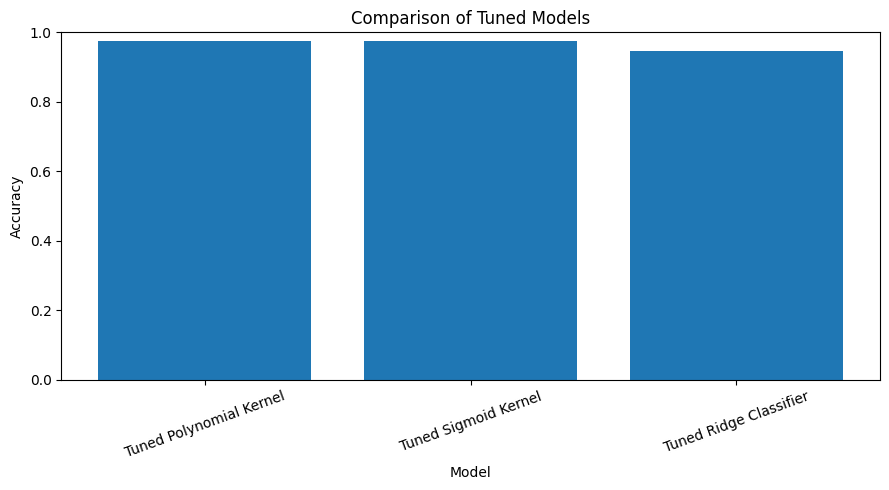

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    tuned_results["Model"],
    tuned_results["Test Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Comparison of Tuned Models")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

#17) Classification report

In [17]:
best_model_name = tuned_results.loc[
    tuned_results["Test Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Tuned Polynomial Kernel


In [18]:
if best_model_name == "Tuned Polynomial Kernel":
    best_predictions = best_poly.predict(X_test)

elif best_model_name == "Tuned Sigmoid Kernel":
    best_predictions = best_sigmoid.predict(X_test)

else:
    best_predictions = best_ridge.predict(X_test)

print(classification_report(
    y_test,
    best_predictions,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



#18) Confusion Matrix

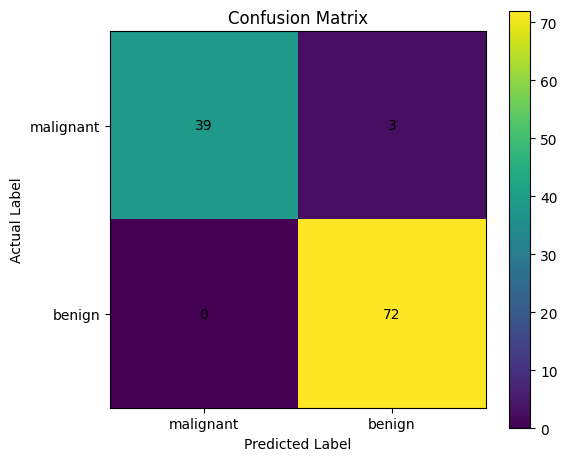

In [19]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.xticks([0, 1], data.target_names)
plt.yticks([0, 1], data.target_names)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

#19) Conclusion


In this experiment, Polynomial Kernel, Sigmoid Kernel and Ridge Classifier were implemented using the Scikit-learn Breast Cancer dataset.

The Polynomial and Sigmoid kernels were implemented using Support Vector Classification, while Ridge Classifier was used to apply L2 regularization for classification.

Hyperparameter tuning was performed using GridSearchCV. Parameters such as C, degree, gamma and alpha were tested to identify the best-performing configurations.

The tuned models were evaluated using test accuracy, classification reports and a confusion matrix.

The experiment demonstrates that selecting suitable hyperparameters can improve the performance of machine learning models and that different kernels behave differently depending on the dataset.